In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
import scqubits as scq

import floquet as ft

### Run for a transmon

In [2]:
filepath = ft.generate_file_path("h5py", "transmon_floquet", "out")

# Transmon parameters
num_states = 20
# These parameters give a transmon with E10 = 5.45 GHz, alpha = -219 MHz
qubit_params = {"EJ": 20.0, "EC": 0.2, "ng": 0.25, "ncut": 41}
tmon = scq.Transmon(**qubit_params, truncated_dim=num_states)
state_indices = [0, 1]  # get data for ground and first excited states


# Express operators in eigenbasis of transmon
def get_H0_H1(qubit_instance):
    hilbert_space = scq.HilbertSpace([qubit_instance])
    hilbert_space.generate_lookup()
    evals = hilbert_space["evals"][0][0:num_states]
    H0 = 2.0 * np.pi * qt.Qobj(np.diag(evals - evals[0]))
    H1 = hilbert_space.op_in_dressed_eigenbasis(qubit_instance.n_operator)
    return H0, H1


H0, H1 = get_H0_H1(tmon)

# Drive parameters
# Drive frequencies to scan over
omega_d_values = 2.0 * np.pi * np.linspace(7.5, 10.0, 120)
# Induced ac stark shifts to scan over
chi_ac_values = 2.0 * np.pi * np.linspace(0.0, 0.1, 59)
# To achieve same range of chi_ac for the various drive frequencies, need different
# drive amplitudes. This utility computes the linear drive strength required to achieve
# a desired induced ac-Stark shift for the various drive frequencies.
chi_to_amp = ft.ChiacToAmp(H0, H1, state_indices, omega_d_values)
# drive_amplitudes has shape (a,w), where a is amplitude and w is frequency
drive_amplitudes = chi_to_amp.amplitudes_for_omega_d(chi_ac_values)

# initialize the model to pass to FloquetAnalysis
model = ft.Model(
    H0, H1, omega_d_values=omega_d_values, drive_amplitudes=drive_amplitudes
)

options = ft.Options(
    fit_range_fraction=0.5,  # split the fit into segments based on this fraction
    floquet_sampling_time_fraction=0.0,  # fraction of the period to compute the Floquet modes  # noqa E501
    fit_cutoff=4,  # polynomial cutoff
    overlap_cutoff=0.9,  # cutoff for excluding from the fit
    nsteps=30_000,  # qutip integration parameter
    num_cpus=6,  # number of cpus to use to compute Floquet modes in parallel
    save_floquet_modes=True,  # whether or not to save floquet modes themselves
)

In [3]:
floquet_analysis = ft.FloquetAnalysis(
    model, state_indices=state_indices, options=options
)
data_vals = floquet_analysis.run(filepath=filepath)

Running floquet simulation with parameters: 
model: H0: Quantum object: dims=[[20], [20]], shape=(20, 20), type='oper', dtype=Dense, isherm=True
Qobj data =
[[  0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.        ]
 [  0.          34.23724704   0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.        ]
 [  0.           0.          67.09785619   0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.        ]
 [  0.           0.           0.          98.47961089   0.
    0.           0.           0.           0.    

In [4]:
new_obj, new_data_dict = ft.read_from_file(filepath)

In [5]:
def print_dict(_dict, iter_val=1):
    iter_tab = "|      " * (iter_val - 1) + "|---> "

    for key, value in _dict.items():
        if isinstance(value, dict):
            print(f"{iter_tab}{key}: {type(value)}")
            print_dict(value, iter_val + 1)
        elif isinstance(value, ft.model.Model) or isinstance(value, ft.options.Options):
            print(f"{iter_tab}{key}: {type(value)}")
            print_dict(value.__dict__, iter_val + 1)
        elif isinstance(value, np.ndarray) or isinstance(value, qt.Qobj):
            print(f"{iter_tab}{key}: ndarray of shape {value.shape}")
        else:
            print(f"{iter_tab}{key}: {value}")


print("new_obj.__dict__:")
print_dict(new_obj.__dict__)
print()
print("new_data_dict:")
print_dict(new_data_dict)

new_obj.__dict__:
|---> model: <class 'floquet.model.Model'>
|      |---> H0: ndarray of shape (20, 20)
|      |---> H1: ndarray of shape (20, 20)
|      |---> omega_d_values: ndarray of shape (120,)
|      |---> drive_amplitudes: ndarray of shape (59, 120)
|---> state_indices: ndarray of shape (2,)
|---> options: <class 'floquet.options.Options'>
|      |---> fit_range_fraction: 0.5
|      |---> floquet_sampling_time_fraction: 0.0
|      |---> fit_cutoff: 4
|      |---> overlap_cutoff: 0.9
|      |---> nsteps: 30000
|      |---> num_cpus: 6
|      |---> save_floquet_modes: True
|---> init_data_to_save: None
|---> hilbert_dim: 20

new_data_dict:
|---> avg_excitation: ndarray of shape (120, 59, 20)
|---> bare_state_overlaps: ndarray of shape (120, 59, 2)
|---> displaced_state_overlaps: ndarray of shape (120, 59, 2)
|---> fit_data: ndarray of shape (2, 20, 9)
|---> floquet_modes: ndarray of shape (120, 59, 2, 20)
|---> intermediate_displaced_state_overlaps: ndarray of shape (120, 59, 2)


In [6]:
def plot_disp_state_ovlps(displaced_state_overlaps, state_idx):
    plot_data = np.clip(1 - displaced_state_overlaps[:, :, state_idx].T ** 2, 0.0, 0.5)

    fig, ax = plt.subplots(figsize=(8, 8))
    xticks = omega_d_values / (2.0 * np.pi)
    yticks = chi_ac_values / (2.0 * np.pi)
    num_x_pts = len(xticks)
    num_y_pts = len(yticks)
    im = plt.imshow(
        plot_data, origin="lower", cmap="Blues", aspect=0.75, interpolation="none"
    )
    ax.set_title(f"$P_{state_idx}$" + r"$\rightarrow$", fontsize=15)
    xticklabel_locations = np.linspace(0, num_x_pts - 1, 6, dtype=int)
    ax.set_xticks(xticklabel_locations)
    ax.set_xticklabels(
        np.array(np.around(xticks[xticklabel_locations], decimals=2), dtype=str),
        fontsize=12,
    )
    yticklabel_locations = np.linspace(0, num_y_pts - 1, 3, dtype=int)
    ax.set_yticks(yticklabel_locations)
    ax.set_yticklabels(
        np.array(np.around(yticks[yticklabel_locations], decimals=2), dtype=str),
        fontsize=12,
    )
    ax.set_ylabel(r"$\chi_{\rm ac}$ [GHz]", fontsize=15)
    ax.set_xlabel(r"$\omega_r/2\pi$ [GHz]", fontsize=15)
    cax = plt.axes([0.91, 0.35, 0.05, 0.3])
    cbar = plt.colorbar(im, cax=cax)
    plt.show()

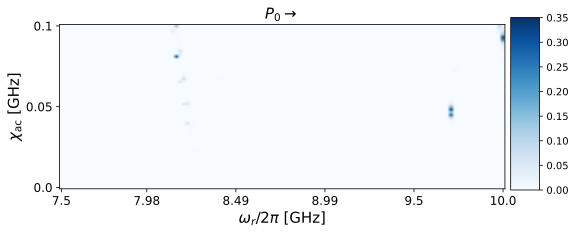

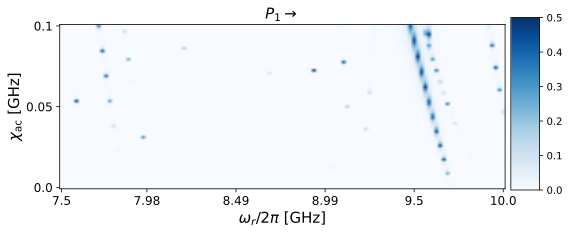

In [7]:
coeffs = new_data_dict["fit_data"]

for i in state_indices:
    plot_disp_state_ovlps(new_data_dict["displaced_state_overlaps"], i)

### Old Code

In [8]:
from floquet import parallel_map


def all_displaced_states(displaced_state, coefficients: np.ndarray) -> np.ndarray:
    def _run_disp(omega_d_amp: tuple[float, float]) -> np.ndarray:
        states = np.zeros(
            (len(displaced_state.state_indices), displaced_state.hilbert_dim),
            dtype=complex,
        )
        omega_d, amp = omega_d_amp
        for array_idx, state_idx in enumerate(displaced_state.state_indices):
            states[array_idx, :] = displaced_state.displaced_state(
                omega_d, amp, state_idx=state_idx, coefficients=coefficients[array_idx]
            ).full()[:, 0]
        return states

    omega_d_amp_params = displaced_state.model.omega_d_amp_params(
        [0, len(displaced_state.model.drive_amplitudes)]
    )
    result = list(
        parallel_map(displaced_state.options.num_cpus, _run_disp, omega_d_amp_params)
    )
    return np.array(result).reshape(
        (
            len(displaced_state.model.omega_d_values),
            len(displaced_state.model.drive_amplitudes),
            len(displaced_state.state_indices),
            displaced_state.hilbert_dim,
        )
    )


# Test overlap with bare states without cartesian enabled
def test_amp_steps(displaced_state, floquet_modes) -> np.ndarray:
    # initialize all arrays that will contain our data
    array_shape = (
        len(displaced_state.model.omega_d_values),
        len(displaced_state.model.drive_amplitudes),
        len(displaced_state.state_indices),
    )

    bare_state_overlaps = np.zeros(array_shape)
    intermediate_overlaps = np.zeros(array_shape)

    # previous coeffs
    coeffs = [
        np.zeros(
            (
                len(displaced_state.state_indices),
                displaced_state.hilbert_dim,
                len(displaced_state._create_exponent_pair_idx_map()),
            )
        )
    ]

    # split into ranges
    num_fit_ranges = int(np.ceil(1 / displaced_state.options.fit_range_fraction))
    num_amp_pts_per_range = int(
        np.floor(len(displaced_state.model.drive_amplitudes) / num_fit_ranges)
    )

    for amp_range_idx in range(num_fit_ranges):
        if amp_range_idx == num_fit_ranges - 1:
            amp_range_idx_final = len(displaced_state.model.drive_amplitudes)
        else:
            amp_range_idx_final = (amp_range_idx + 1) * num_amp_pts_per_range
        amp_idxs = [amp_range_idx * num_amp_pts_per_range, amp_range_idx_final]

        # get floquet modes for this range
        floquet_modes_for_range = floquet_modes[:, amp_idxs[0] : amp_idxs[1], ...]

        # bare state overlaps
        ovlp_with_bare_states = displaced_state.overlap_with_bare_states(
            coefficients=coeffs[-1],
            floquet_modes=floquet_modes_for_range,
            amp_idx_0=amp_idxs[0],
        )
        bare_state_overlaps[:, amp_idxs[0] : amp_idxs[1], :] = ovlp_with_bare_states

        # new coeffs (recheck)
        omega_d_amp_slice = list(model.omega_d_amp_params(amp_idxs))
        new_coefficients = displaced_state.displaced_states_fit(
            omega_d_amp_slice, ovlp_with_bare_states, floquet_modes_for_range
        )

        # # intermediate displaced state overlaps
        overlaps = displaced_state.overlap_with_displaced_states(
            amp_idxs, new_coefficients, floquet_modes
        )
        intermediate_overlaps[:, amp_idxs[0] : amp_idxs[1], :] = overlaps

        # reassign previous coefficients for next iteration
        coeffs.append(new_coefficients)

    return bare_state_overlaps, intermediate_overlaps, coeffs

In [9]:
displaced_state = ft.DisplacedStateFit(
    hilbert_dim=new_obj.hilbert_dim,
    model=new_obj.model,
    state_indices=new_obj.state_indices,
    options=options,
)

amp_idxs = [0, len(model.drive_amplitudes)]

In [10]:
# Compute the displaced states using the fit coefficients
displaced_states1 = all_displaced_states(displaced_state, coeffs)
assert displaced_states1.shape == (
    len(model.omega_d_values),
    len(model.drive_amplitudes),
    len(new_obj.state_indices),
    new_obj.hilbert_dim,
)

# Compute overlaps with displaced states using the fit coefficients
displaced_state_overlaps1 = displaced_state.overlap_with_displaced_states(
    amp_idxs, coeffs, new_data_dict["floquet_modes"]
)

print(f"displaced_state_overlaps1.shape = {displaced_state_overlaps1.shape}")
assert np.allclose(displaced_state_overlaps1, new_data_dict["displaced_state_overlaps"])

# Refit the coefficients
coeffs1 = displaced_state.displaced_states_fit(
    omega_d_amp_slice=list(model.omega_d_amp_params(amp_idxs)),
    ovlp_with_bare_states=new_data_dict["intermediate_displaced_state_overlaps"],
    floquet_modes=new_data_dict["floquet_modes"],
)
assert np.allclose(coeffs1, coeffs)
print(f"coeffs1.shape = {coeffs1.shape}")

# Recompute the bare and intermediate overlaps
bare_state_overlaps1, intermediate_overlaps1, intermediate_coeffs1 = test_amp_steps(
    displaced_state, new_data_dict["floquet_modes"]
)
print(f"bare_state_overlaps1.shape = {bare_state_overlaps1.shape}")
print(f"intermediate_overlaps1.shape = {intermediate_overlaps1.shape}")

assert np.allclose(bare_state_overlaps1, new_data_dict["bare_state_overlaps"])
assert np.allclose(
    intermediate_overlaps1, new_data_dict["intermediate_displaced_state_overlaps"]
)

print("All checks passed!")

displaced_state_overlaps1.shape = (120, 59, 2)
coeffs1.shape = (2, 20, 9)
bare_state_overlaps1.shape = (120, 59, 2)
intermediate_overlaps1.shape = (120, 59, 2)
All checks passed!


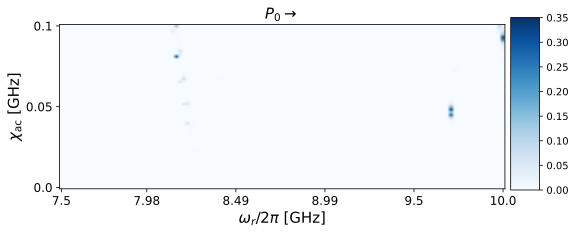

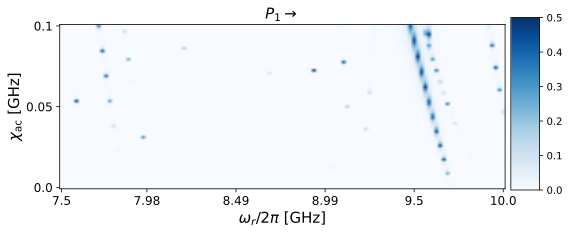

In [11]:
for i in state_indices:
    plot_disp_state_ovlps(displaced_state_overlaps1, i)

### New code

In [43]:
# Test overlap with bare states without cartesian enabled
def test_amp_steps(displaced_state, floquet_modes) -> np.ndarray:
    # initialize all arrays that will contain our data
    array_shape = (
        len(displaced_state.model.omega_d_values),
        len(displaced_state.model.drive_amplitudes),
        len(displaced_state.state_indices),
    )

    bare_state_overlaps = np.zeros(array_shape)
    intermediate_overlaps = np.zeros(array_shape)

    # previous coeffs
    coeffs = [
        np.zeros(
            (
                len(displaced_state.state_indices),
                displaced_state.hilbert_dim,
                displaced_state.exponent_pairs.shape[-1],
            )
        )
    ]

    # split into ranges
    num_fit_ranges = int(np.ceil(1 / displaced_state.options.fit_range_fraction))
    num_amp_pts_per_range = int(
        np.floor(len(displaced_state.model.drive_amplitudes) / num_fit_ranges)
    )

    for amp_range_idx in range(num_fit_ranges):
        if amp_range_idx == num_fit_ranges - 1:
            amp_range_idx_final = len(displaced_state.model.drive_amplitudes)
        else:
            amp_range_idx_final = (amp_range_idx + 1) * num_amp_pts_per_range
        amp_idxs = [amp_range_idx * num_amp_pts_per_range, amp_range_idx_final]

        # get floquet modes for this range
        floquet_modes_for_range = floquet_modes[:, amp_idxs[0] : amp_idxs[1], ...]

        # bare state overlaps
        ovlp_with_bare_states = displaced_state.overlap_with_bare_states(
            coefficients=coeffs[-1],
            floquet_modes=floquet_modes_for_range,
            amp_idx_0=amp_idxs[0],
        )
        bare_state_overlaps[:, amp_idxs[0] : amp_idxs[1], :] = ovlp_with_bare_states

        # Compare
        to_compare = bare_state_overlaps1[:, amp_idxs[0] : amp_idxs[1], :]
        print(f"ovlp_with_bare_states.shape = {ovlp_with_bare_states.shape}")
        print(f"to_compare.shape = {to_compare.shape}")
        assert np.allclose(ovlp_with_bare_states, to_compare)

        # new coeffs
        new_coefficients, _ = displaced_state.displaced_states_fit(
            ovlp_with_bare_states, floquet_modes_for_range, amp_idxs=amp_idxs
        )

        to_compare = intermediate_coeffs1[amp_range_idx + 1]

        if not np.allclose(new_coefficients, to_compare):
            print(
                f"coeffs not close! max abs diff = {np.max(np.abs(new_coefficients - to_compare)):3e}"
            )

            fig, ax = plt.subplots(
                1, 2, figsize=(7, 6), constrained_layout=True, sharex=True, sharey=True
            )

            im0 = ax[0].imshow(
                np.abs(new_coefficients[0] - to_compare[0]), origin="lower"
            )
            ax[0].set_title("Abs val diff, state_idx = 0")
            fig.colorbar(im0, ax=ax[0], shrink=0.7)

            im1 = ax[1].imshow(
                np.abs(new_coefficients[1] - to_compare[1]), origin="lower"
            )
            ax[1].set_title("Abs val diff, state_idx = 1")
            fig.colorbar(im1, ax=ax[1], shrink=0.7)

            ax[0].set_ylabel("Hilbert space index")
            ax[0].set_xlabel("Fit term index")
            ax[1].set_xlabel("Fit term index")

            plt.show()

            # intermediate displaced state overlaps
            overlaps = displaced_state.overlap_with_displaced_states(
                new_coefficients, floquet_modes, amp_idxs=amp_idxs
            )
            intermediate_overlaps[:, amp_idxs[0] : amp_idxs[1], :] = overlaps

        # get corresponding intermediate states
        displaced_states = displaced_state.displaced_state(
            new_coefficients, amp_idxs=amp_idxs
        )

        to_compare = displaced_state.displaced_state(
            intermediate_coeffs1[amp_range_idx + 1], amp_idxs=amp_idxs
        )

        # and their overlaps
        ovlp_with_intermediate_states = displaced_state.overlap_with_displaced_states(
            new_coefficients, new_data_dict["floquet_modes"], amp_idxs=amp_idxs
        )
        intermediate_overlaps[:, amp_idxs[0] : amp_idxs[1], :] = (
            ovlp_with_intermediate_states
        )

        if not np.allclose(displaced_states, to_compare):
            print(
                f"displaced_states not close! max abs diff = {np.max(np.abs(displaced_states - to_compare)):3e}"
            )

            to_compare1 = displaced_state.overlap_with_displaced_states(
                intermediate_coeffs1[amp_range_idx + 1],
                new_data_dict["floquet_modes"],
                amp_idxs=amp_idxs,
            )

            to_compare2 = intermediate_overlaps1[:, amp_idxs[0] : amp_idxs[1], :]

            fig, ax = plt.subplots(2, 2, figsize=(12, 5), constrained_layout=True)
            for i in range(2):
                data = (
                    np.abs(ovlp_with_intermediate_states[..., i]) ** 2
                    - np.abs(to_compare2[..., i]) ** 2
                )
                im = ax[0, i].imshow(data.T, origin="lower")
                ax[0, i].set_title(
                    f"Inter. ovlps. (with newly derived coeffs), state_idx={i}"
                )
                fig.colorbar(im, ax=ax[0, i], shrink=0.7)

                data = (
                    np.abs(to_compare1[..., i]) ** 2 - np.abs(to_compare2[..., i]) ** 2
                )
                im = ax[1, i].imshow(data.T, origin="lower")
                ax[1, i].set_title(
                    f"Inter. ovlps. (with original coeffs), state_idx={i}"
                )
                fig.colorbar(im, ax=ax[1, i], shrink=0.7)

                for j in range(2):
                    xticks = omega_d_values / (2.0 * np.pi)
                    yticks = chi_ac_values[amp_idxs[0] : amp_idxs[1]] / (2.0 * np.pi)

                    num_x_pts = len(xticks)
                    num_y_pts = len(yticks)

                    xticklabel_locations = np.linspace(0, num_x_pts - 1, 6, dtype=int)
                    ax[j, i].set_xticks(xticklabel_locations)
                    ax[j, i].set_xticklabels(
                        np.array(
                            np.around(xticks[xticklabel_locations], decimals=2),
                            dtype=str,
                        )
                    )
                    yticklabel_locations = np.linspace(0, num_y_pts - 1, 3, dtype=int)
                    ax[j, i].set_yticks(yticklabel_locations)
                    ax[j, i].set_yticklabels(
                        np.array(
                            np.around(yticks[yticklabel_locations], decimals=2),
                            dtype=str,
                        )
                    )

            plt.show()

        # reassign previous coefficients for next iteration
        coeffs.append(new_coefficients)

    return bare_state_overlaps, intermediate_overlaps, coeffs

In [44]:
import warnings

import numpy as np

from floquet.model import Model
from floquet.options import Options
from floquet.utils.parallel import parallel_map


# a little hacky
def model_bare_state_array(model):
    return np.identity(model.H0.shape[-1])


class DisplacedState:
    """Class providing methods for computing displaced states.

    Parameters:
        hilbert_dim: Hilbert space dimension
        model: Model including the Hamiltonian, drive amplitudes, frequencies,
            state indices
        state_indices: States of interest
        options: Options used
    """

    def __init__(
        self, hilbert_dim: int, model: Model, state_indices: list, options: Options
    ):
        self.hilbert_dim = hilbert_dim
        self.model = model
        self.state_indices = state_indices
        self.options = options
        self.exponent_pairs = self._create_exponent_pairs()
        self.poly_terms = self._create_poly_terms()

    def overlap_with_bare_states(
        self,
        coefficients: np.ndarray,
        floquet_modes: np.ndarray,
        omega_d_idxs: tuple[int, int] = (0, None),
        amp_idx_0: int = 0,
        cartesian_overlaps: bool = False,
    ) -> np.ndarray:
        """Calculate overlap of floquet modes with 'bare' states.

        'Bare' here is defined loosely. For the first range of amplitudes, the bare
        states are truly the bare states (all zero coefficients). For later ranges, we
        define the bare state as the state obtained from the fit from previous range,
        with amplitude evaluated at the lower edge of amplitudes for the new region.
        This is, in a sense, the most natural choice, since it is most analogous to what
        is done in the first window when the overlap is computed against bare
        eigenstates (that obviously don't have amplitude dependence). Moreover, the fit
        coefficients for the previous window by definition were obtained in a window
        that does not include the one we are currently investigating. Asking for the
        state with amplitude values outside of the fit window should be done at your
        own peril.

        Parameters:
            coefficients: coefficients that specify the bare state that we calculate
                overlaps of Floquet modes against.
                Shape: (num_states, hilbert_dim, num_fit_terms).
            floquet_modes: Floquet modes to be compared to the bare states given by
                coefficients. The -2 dimension here indexes the modes and the
                -1 dimension indexes the hilbert space.
                Shape: (num_omega_d, num_amps, hilbert_dim, hilbert_dim).
            omega_d_idxs : Indices specifying the lower and upper bound of the drive
                frequency range. Selects all `self.model.omega_d_values` by default.
            amp_idx_0: Index specifying the lower bound of the amplitude range.
                0 by default, i.e. selects the undriven states.
            cartesian_overlaps: If True, compute overlaps between all possible pairs of
                displaced states and floquet modes. If False, only compute overlaps of
                each floquet mode with the corresponding displaced state.
        Returns:
            Overlaps between the floquet modes and corresponding the displaced states
                specified by self.state_indices.
                Shape: (num_omega_d, num_amps, num_states).
        """
        floquet_modes = floquet_modes[
            omega_d_idxs[0] : omega_d_idxs[1], :, self.state_indices, :
        ]
        displaced_states = self.displaced_state(
            coefficients, omega_d_idxs, [amp_idx_0, amp_idx_0 + 1]
        )[:, 0, ...]

        return np.abs(
            np.einsum("wsh,wash->was", np.conj(displaced_states), floquet_modes)
        )

    def overlap_with_displaced_states(
        self,
        coefficients: np.ndarray,
        floquet_modes: np.ndarray,
        omega_d_idxs: tuple[int, int] = (0, None),
        amp_idxs: tuple[int, int] = (0, None),
    ) -> np.ndarray:
        """Calculate overlap of floquet modes with 'ideal' displaced states.

        This is done here for a specific amplitude range.

        Parameters:
            coefficients: coefficients that specify the displaced state that we calculate
                overlaps of Floquet modes against.
                Shape: (num_states, hilbert_dim, num_fit_terms).
            floquet_modes: Floquet modes to be compared to the bare states given by
                coefficients.
                Shape: (num_omega_ds, num_amps, num_states, hilbert_dim).
            omega_d_idxs : Indices specifying the lower and upper bound of the drive
                frequency range. Selects all `self.model.omega_d_values` by default.
            amp_idxs: Indices specifying the lower and upper bound of the amplitude range.
                Selects all self.model.drive_amplitudes by default.
        Returns:
            Overlaps. Shape: (num_omega_ds, num_amps, num_states).
        """
        floquet_modes = floquet_modes[
            omega_d_idxs[0] : omega_d_idxs[1],
            amp_idxs[0] : amp_idxs[1],
            self.state_indices,
            :,
        ]
        displaced_states = self.displaced_state(coefficients, omega_d_idxs, amp_idxs)
        return np.abs(
            np.einsum("wash,wash->was", np.conj(displaced_states), floquet_modes)
        )

    def displaced_state(
        self,
        coefficients: np.ndarray,
        omega_d_idxs: tuple[int, int] = (0, None),
        amp_idxs: tuple[int, int] = (0, None),
    ) -> np.ndarray:
        """Construct the ideal displaced state, $\left| \tilde{n} (\omega_d, \Omega_d) \right>$ based on a low-order perturbation around the corresponding bare state.
        $$
        \left| \tilde{n} (\omega_d, \Omega_d) \right> = \left| n \right> + \sum_l \sum_{k_0, k_1} c_{n, l, k_0, k_1} \omega_d^{k_0} \Omega_d^{k_1} \left| l \right>
        $$
        where the coefficients $c_{n, l, k_0, k_1}$ are provided in the `coefficients` argument.
        The constant term (i.e. $k_0 = k_1 = 0$) is excluded from the fit, as indicated by the
        Kronecker delta $\delta_{n,l}$. Note, that the (k_0, k_1) indices are stacked, and provided
        in the order specified by `self.exponent_pairs`.

        Parameters:
            coefficients: Coefficients to expand the displaced state in terms of the undriven
                states. Shape: (num_states, hilbert_dim, num_fit_terms).
            omega_d_idxs : Indices specifying the lower and upper bound of the drive
                frequency range. Selects all `self.model.omega_d_values` by default.
            amp_idxs: Indices specifying the lower and upper bound of the amplitude range.
                Selects all self.model.drive_amplitudes by default.

        Returns:
            The displaced state(s). Shape: (num_omega_ds, num_amps, num_states, hilbert_dim).
            Careful, that the num_states index is the array index, not the state index! For example,
            if state_indices = [0, 2], then result[0, ...] is the displaced state for state index
            0, and result[1, ...] is the displaced state for state index 2.
        """
        # Tensor of polynomial terms omega^{k_0} * amp^{k_1}.
        # Shape: (num_omega_ds, num_amps, num_fit_terms)
        _poly_terms = self.poly_terms[
            omega_d_idxs[0] : omega_d_idxs[1], amp_idxs[0] : amp_idxs[1], :
        ]

        # Compute the perturbation, based on the given coefficients.
        result = np.einsum("wat,sht->wash", _poly_terms, coefficients)

        # Add the perturbation to the bare state. Bare states are defined by the model.
        # Get only the states corresponding to state_indices, and tile them for all
        # omega_ds and amps.
        result += np.tile(
            model_bare_state_array(self.model)[None, None, self.state_indices, :],
            (*result.shape[:2], 1, 1),
        )

        # Normalize
        result /= np.linalg.norm(result, axis=-1, keepdims=True)

        return result

    def _create_poly_terms(self) -> np.ndarray:
        """Compute a tensor, where each component is a polynomial term
        omega^{k_0} * amp^{k_1} for all (omega, amp, fit_terms).
        """
        omega_power = (
            self.model.omega_d_values[:, None, None]
            ** self.exponent_pairs[0][None, None, :]
        )
        amp_power = (
            self.model.drive_amplitudes.T[:, :, None]
            ** self.exponent_pairs[1][None, None, :]
        )
        return omega_power * amp_power

    def _create_exponent_pairs(self) -> np.ndarray:
        """Create dictionary of terms in polynomial that we fit.

        We truncate the fit if e.g. there is only a single frequency value to scan over
        but the fit is nominally set to order four. We additionally eliminate the
        constant term that should always be either zero or one.
        """
        cutoff_omega_d = min(len(self.model.omega_d_values), self.options.fit_cutoff)
        cutoff_amp = min(len(self.model.drive_amplitudes), self.options.fit_cutoff)
        # Generate all combinations of indices.
        # Remove amplitude-independent terms (i.e. when the exponent for the amp == 0).
        # This is enforced by the fact the states have to agree at zero drive strength.
        idx_exp_map = np.stack(
            np.meshgrid(
                np.arange(cutoff_omega_d), np.arange(1, cutoff_amp), indexing="ij"
            ),
            axis=-1,
        ).reshape(-1, 2)

        # Only keep terms where the sum of the exponents is less than the cutoff
        idx_exp_map = idx_exp_map[
            np.sum(idx_exp_map, axis=-1) <= self.options.fit_cutoff
        ]

        # Sort. Introduce a fudge factor to ensure that the sorting is stable
        # Only keep terms where the sum of the exponents is less than the cutoff
        weighted_vals = 1.01 * idx_exp_map[:, 0] + idx_exp_map[:, 1]
        sorted_idxs = np.argsort(weighted_vals)
        return idx_exp_map[sorted_idxs].T


class DisplacedStateFit(DisplacedState):
    """Methods for fitting an ideal displaced state to calculated Floquet modes."""

    def displaced_states_fit(
        self,
        ovlp_with_bare_states: np.ndarray,
        floquet_modes: np.ndarray,
        omega_d_idxs: tuple[int, int] = (0, None),
        amp_idxs: tuple[int, int] = (0, None),
    ) -> np.ndarray:
        """Perform a fit for the indicated range, ignoring specified modes.

        We loop over all states in state_indices and perform the fit for a given
        amplitude range. We ignore floquet modes (not included in the fit) where
        the corresponding value in ovlp_with_bare_states is below the threshold
        specified in options.

        Parameters:
            ovlp_with_bare_states: Overlap with bare states. Already trimmed to the
                relevant range of frequencies and amplitudes.
                Shape: (num_omega_d_in_range, num_amps_in_range, num_states).
            floquet_modes: Floquet modes.
                Shape: (num_omega_ds, num_amps, num_states, hilbert_dim).
            omega_d_idxs : Indices specifying the lower and upper bound of the drive
                frequency range. Selects all `self.model.omega_d_values` by default.
            amp_idxs: Indices specifying the lower and upper bound of the amplitude range.
                Selects all self.model.drive_amplitudes by default.

        Returns:
            Optimized fit coefficients. Shape: (num_states, hilbert_dim, num_fit_terms).
        """

        # Only fit states that we think haven't run into a transition,
        # and those within the specified bounds
        # mask.shape = (num_omega_ds, num_amps, num_state_indices).
        mask = ovlp_with_bare_states > self.options.overlap_cutoff

        # Required poly_terms
        poly_terms = self.poly_terms[
            omega_d_idxs[0] : omega_d_idxs[1], amp_idxs[0] : amp_idxs[1], :
        ]

        coeffs = np.zeros(
            (len(self.state_indices), self.hilbert_dim, self.exponent_pairs.shape[-1]),
            dtype=complex,
        )

        # Fit each state separately, since their masks may differ
        for arr_idx, state_idx in enumerate(self.state_indices):
            coeffs[arr_idx] = self._fit_for_state_idx(
                target_states=floquet_modes[..., state_idx, :],
                mask=mask[..., state_idx],
                state_index=state_idx,
                poly_terms=poly_terms,
            )

        # TODO: return mask, other fit data
        return coeffs, mask

    def _fit_for_state_idx(
        self,
        target_states: np.ndarray,
        mask: np.ndarray,
        state_index: int,
        poly_terms: np.ndarray,
    ) -> np.ndarray:
        num_fit_terms = self.exponent_pairs.shape[-1]
        mask_flat = mask.ravel()

        # Warn if not enough data points to fit
        if np.count_nonzero(mask_flat) < num_fit_terms:
            warnings.warn(
                "Not enough data points to fit. Returning zeros for the fit",
                stacklevel=3,
            )
            return np.zeros((self.hilbert_dim, num_fit_terms), dtype=complex)

        # Flatten and mask arrays. Resulting rows index masked amp-freq pairs.
        # For the poly_terms matrix, the cols index the fit terms.
        # For states, the cols index the hilbert_dim
        # masked_poly_terms = poly_terms.reshape(-1, num_fit_terms)[mask_flat]
        # masked_target_states = target_states.reshape(-1, self.hilbert_dim)[mask_flat]

        masked_poly_terms = np.array(
            [poly_terms[..., t].ravel()[mask_flat] for t in range(num_fit_terms)]
        ).T
        masked_target_states = np.array(
            [target_states[..., h].ravel()[mask_flat] for h in range(self.hilbert_dim)]
        ).T

        # Bare states array (repeated for all amp-freq pairs)
        masked_bare_states = np.tile(
            model_bare_state_array(self.model)[None, state_index, :],
            (masked_target_states.shape[0], 1),
        )

        # Fit the difference between the target states and the bare states
        masked_states_to_fit = masked_target_states - masked_bare_states

        if np.any(np.abs(masked_states_to_fit) > 1):
            raise RuntimeError("Large values to fit. Fit may be unreliable.")

        # Simple linear fit: masked_states_to_fit = masked_poly_terms @ coefficients.T
        try:
            popt = np.linalg.lstsq(masked_poly_terms, masked_states_to_fit)[0].T

        except np.linalg.LinAlgError:
            warnings.warn("Fit failed. Returning zeros for the fit", stacklevel=3)
            popt = np.zeros((self.hilbert_dim, num_fit_terms), dtype=complex)

        return popt

 <>: 127SyntaxWarning: invalid escape sequence '\l'
 <>: 127SyntaxWarning: invalid escape sequence '\l'
 /var/folders/fp/l4vdxgfn2jlgsvk5fw41sfyr0000gn/T/ipykernel_12786/1522562586.py: 127

In [45]:
displaced_state = DisplacedStateFit(
    hilbert_dim=new_obj.hilbert_dim,
    model=new_obj.model,
    state_indices=new_obj.state_indices,
    options=options,
)

coeffs = new_data_dict["fit_data"]

In [46]:
# Compute the displaced states using the fit coefficients
displaced_states2 = displaced_state.displaced_state(coefficients=coeffs)
assert displaced_states2.shape == (
    len(model.omega_d_values),
    len(model.drive_amplitudes),
    len(new_obj.state_indices),
    new_obj.hilbert_dim,
)
assert np.allclose(displaced_states2, displaced_states1)

# Compute overlaps with displaced states using the fit coefficients
print(new_data_dict["floquet_modes"].shape)
displaced_state_overlaps2 = displaced_state.overlap_with_displaced_states(
    coeffs, new_data_dict["floquet_modes"]
)

print(f"displaced_state_overlaps2.shape = {displaced_state_overlaps2.shape}")
assert np.allclose(displaced_state_overlaps2, new_data_dict["displaced_state_overlaps"])

# New fit
coeffs2, _ = displaced_state.displaced_states_fit(
    ovlp_with_bare_states=new_data_dict["intermediate_displaced_state_overlaps"],
    floquet_modes=new_data_dict["floquet_modes"],
)
print(f"coeffs2.shape = {coeffs2.shape}")
displaced_states2_new = displaced_state.displaced_state(coefficients=coeffs2)

print("All checks passed!")

(120, 59, 2, 20)
displaced_state_overlaps2.shape = (120, 59, 2)
coeffs2.shape = (2, 20, 9)
All checks passed!


ovlp_with_bare_states.shape = (120, 29, 2)
to_compare.shape = (120, 29, 2)
coeffs not close! max abs diff = 3.807578e-05


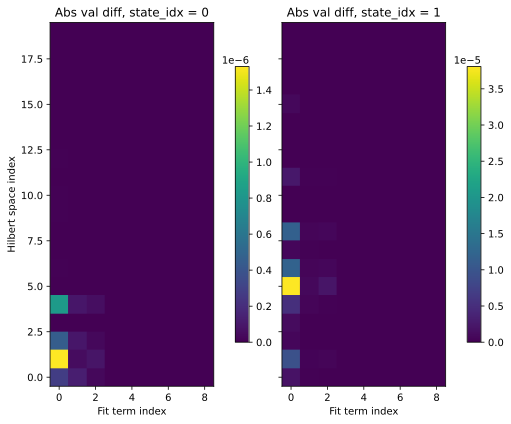

displaced_states not close! max abs diff = 4.626037e-07


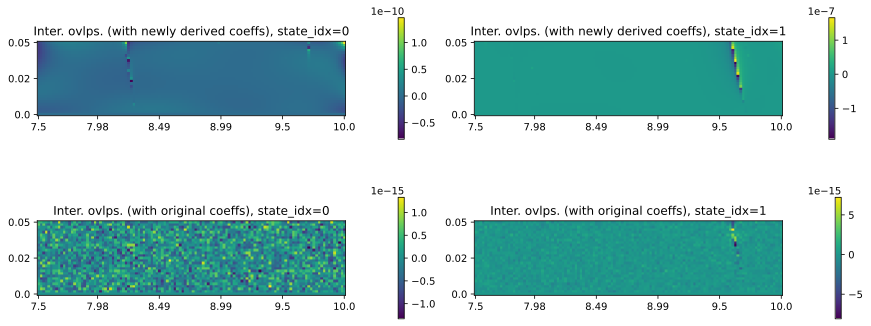

ovlp_with_bare_states.shape = (120, 30, 2)
to_compare.shape = (120, 30, 2)
coeffs not close! max abs diff = 8.678467e-05


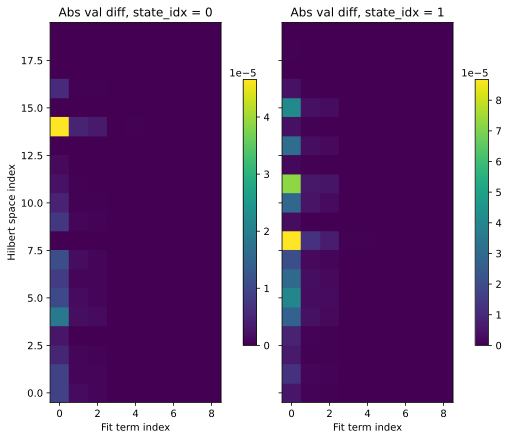

displaced_states not close! max abs diff = 1.849466e-06


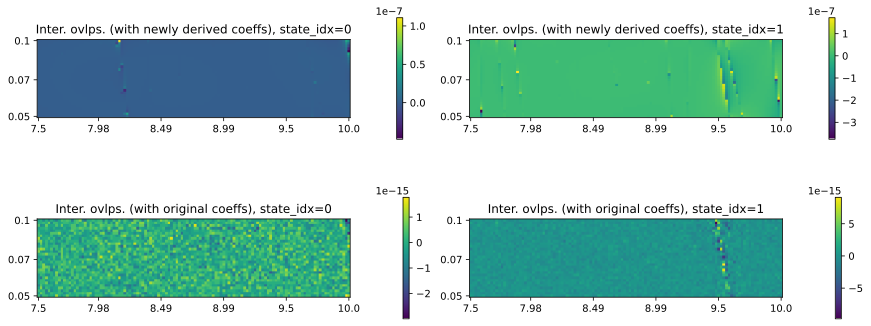

bare_state_overlaps2.shape = (120, 59, 2)
intermediate_overlaps2.shape = (120, 59, 2)


In [47]:
# Recompute the bare and intermediate overlaps
bare_state_overlaps2, intermediate_overlaps2, intermediate_coeffs2 = test_amp_steps(
    displaced_state, new_data_dict["floquet_modes"]
)
print(f"bare_state_overlaps2.shape = {bare_state_overlaps2.shape}")
print(f"intermediate_overlaps2.shape = {intermediate_overlaps2.shape}")

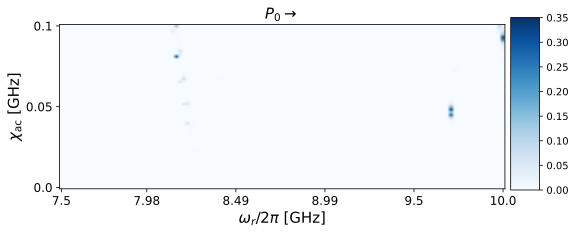

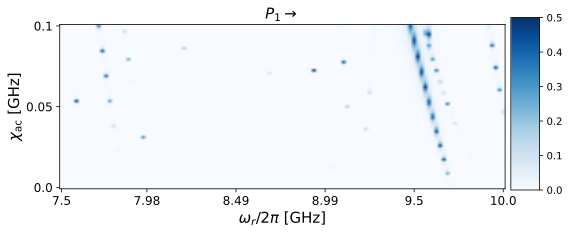

In [48]:
for i in state_indices:
    plot_disp_state_ovlps(displaced_state_overlaps2, i)

Compare the displaced states

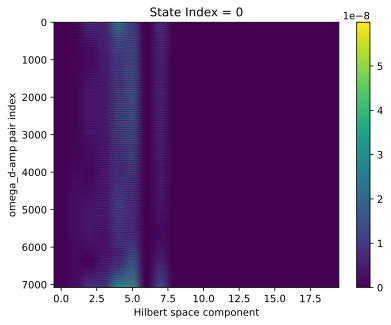

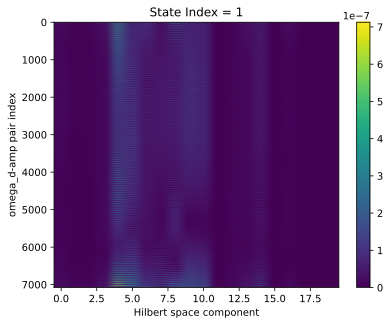

In [49]:
for i in new_obj.state_indices:
    diff = np.abs(displaced_states2_new[..., i, :] - displaced_states1[..., i, :])
    diff = diff.reshape(-1, displaced_state.hilbert_dim)
    plt.imshow(diff, aspect="auto", interpolation=None)
    plt.colorbar()
    plt.title(f"State Index = {i}")
    plt.ylabel(f"omega_d-amp pair index")
    plt.xlabel(f"Hilbert space component")
    plt.show()

Compare the overlaps for the new fit

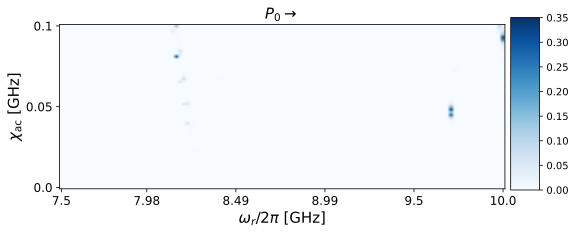

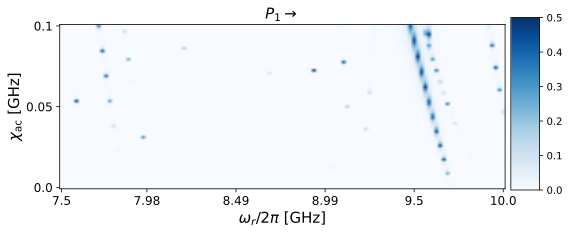

In [91]:
displaced_state_overlaps2_new = displaced_state.overlap_with_displaced_states(
    coeffs2, new_data_dict["floquet_modes"]
)

for i in state_indices:
    plot_disp_state_ovlps(displaced_state_overlaps2_new, i)

# Scratch

amp_idxs = [0, 29]
ovlp_with_bare_states.shape = (120, 29, 2)
to_compare.shape = (120, 29, 2)
new_coefficients.shape = (2, 20, 9)
to_compare.shape = (2, 20, 9)
coeffs not close! max abs diff = 2.938121e-04


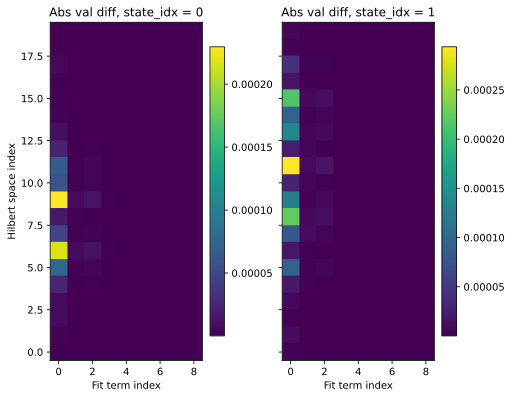

displaced_states not close! max abs diff = 3.441369e-05
Computing intermediate overlaps to identify where the discrepancy is coming from...


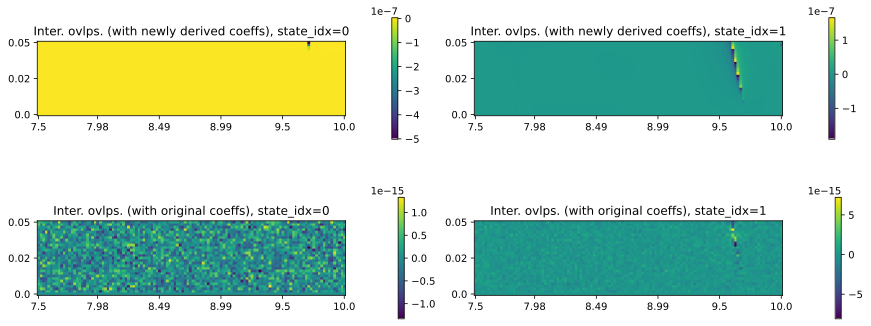

amp_idxs = [29, 59]
ovlp_with_bare_states.shape = (120, 30, 2)
to_compare.shape = (120, 30, 2)
new_coefficients.shape = (2, 20, 9)
to_compare.shape = (2, 20, 9)
coeffs not close! max abs diff = 7.441762e-04


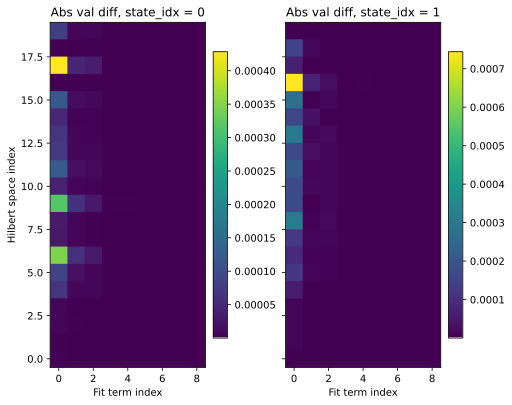

displaced_states not close! max abs diff = 6.574090e-05
Computing intermediate overlaps to identify where the discrepancy is coming from...


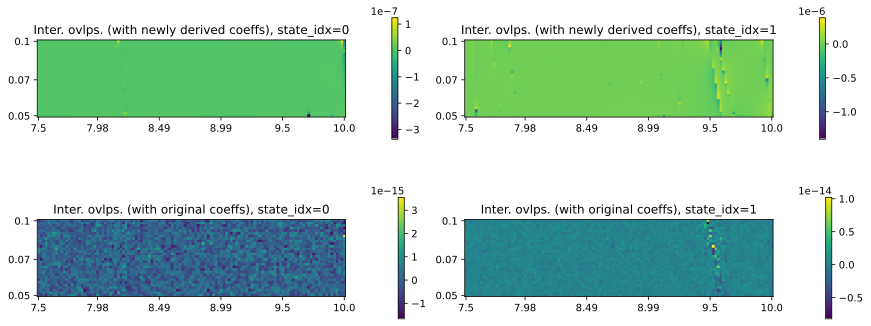

In [81]:
# split into ranges
num_fit_ranges = int(np.ceil(1 / displaced_state.options.fit_range_fraction))
num_amp_pts_per_range = int(
    np.floor(len(displaced_state.model.drive_amplitudes) / num_fit_ranges)
)

###########


def main_for_amp_range(amp_range_idx, coeffs):
    if amp_range_idx == num_fit_ranges - 1:
        amp_range_idx_final = len(displaced_state.model.drive_amplitudes)
    else:
        amp_range_idx_final = (amp_range_idx + 1) * num_amp_pts_per_range
    amp_idxs = [amp_range_idx * num_amp_pts_per_range, amp_range_idx_final]

    print(f"amp_idxs = {amp_idxs}")

    # get floquet modes for this range
    floquet_modes_for_range = new_data_dict["floquet_modes"][
        :, amp_idxs[0] : amp_idxs[1], ...
    ]

    ###########
    # bare state overlaps
    ovlp_with_bare_states = displaced_state.overlap_with_bare_states(
        coefficients=coeffs[-1],
        floquet_modes=floquet_modes_for_range,
        amp_idx_0=amp_idxs[0],
    )

    to_compare = bare_state_overlaps1[:, amp_idxs[0] : amp_idxs[1], :]
    print(f"ovlp_with_bare_states.shape = {ovlp_with_bare_states.shape}")
    print(f"to_compare.shape = {to_compare.shape}")
    assert np.allclose(ovlp_with_bare_states, to_compare)

    # new coeffs
    new_coefficients = displaced_state.displaced_states_fit(
        ovlp_with_bare_states, floquet_modes_for_range, amp_idxs=amp_idxs
    )

    to_compare = intermediate_coeffs1[amp_range_idx + 1]
    print(f"new_coefficients.shape = {new_coefficients.shape}")
    print(f"to_compare.shape = {to_compare.shape}")
    if not np.allclose(new_coefficients, to_compare):
        print(
            f"coeffs not close! max abs diff = {np.max(np.abs(new_coefficients - to_compare)):3e}"
        )

        fig, ax = plt.subplots(
            1, 2, figsize=(7, 6), constrained_layout=True, sharex=True, sharey=True
        )
        ax = ax.flatten()

        im0 = ax[0].imshow(np.abs(new_coefficients[0] - to_compare[0]), origin="lower")
        ax[0].set_title("Abs val diff, state_idx = 0")
        fig.colorbar(im0, ax=ax[0], shrink=0.7)

        im1 = ax[1].imshow(np.abs(new_coefficients[1] - to_compare[1]), origin="lower")
        ax[1].set_title("Abs val diff, state_idx = 1")
        fig.colorbar(im1, ax=ax[1], shrink=0.7)

        # im2 = ax[2].imshow(np.angle(new_coefficients[0] - to_compare[0]), origin='lower')
        # ax[2].set_title('Angle diff, state_idx = 0')
        # fig.colorbar(im2, ax=ax[2], shrink=0.7)

        # im3 = ax[3].imshow(np.angle(new_coefficients[1] - to_compare[1]), origin='lower')
        # ax[3].set_title('Angle diff, state_idx = 1')
        # fig.colorbar(im3, ax=ax[3], shrink=0.7)

        ax[0].set_ylabel("Hilbert space index")
        ax[0].set_xlabel("Fit term index")
        ax[1].set_xlabel("Fit term index")

        plt.show()

    # get corresponding intermediate states
    displaced_states = displaced_state.displaced_state(
        new_coefficients, amp_idxs=amp_idxs
    )

    to_compare = displaced_state.displaced_state(
        intermediate_coeffs1[amp_range_idx + 1], amp_idxs=amp_idxs
    )

    if not np.allclose(displaced_states, to_compare):
        print(
            f"displaced_states not close! max abs diff = {np.max(np.abs(displaced_states - to_compare)):3e}"
        )

        print(
            "Computing intermediate overlaps to identify where the discrepancy is coming from..."
        )
        intermediate_overlaps = displaced_state.overlap_with_displaced_states(
            new_coefficients, new_data_dict["floquet_modes"], amp_idxs=amp_idxs
        )

        to_compare1 = displaced_state.overlap_with_displaced_states(
            intermediate_coeffs1[amp_range_idx + 1],
            new_data_dict["floquet_modes"],
            amp_idxs=amp_idxs,
        )

        to_compare2 = intermediate_overlaps1[:, amp_idxs[0] : amp_idxs[1], :]

        fig, ax = plt.subplots(2, 2, figsize=(12, 5), constrained_layout=True)
        for i in range(2):
            data = (
                np.abs(intermediate_overlaps[..., i]) ** 2
                - np.abs(to_compare2[..., i]) ** 2
            )
            im = ax[0, i].imshow(data.T, origin="lower")
            ax[0, i].set_title(
                f"Inter. ovlps. (with newly derived coeffs), state_idx={i}"
            )
            fig.colorbar(im, ax=ax[0, i], shrink=0.7)

            data = np.abs(to_compare1[..., i]) ** 2 - np.abs(to_compare2[..., i]) ** 2
            im = ax[1, i].imshow(data.T, origin="lower")
            ax[1, i].set_title(f"Inter. ovlps. (with original coeffs), state_idx={i}")
            fig.colorbar(im, ax=ax[1, i], shrink=0.7)

            for j in range(2):
                xticks = omega_d_values / (2.0 * np.pi)
                yticks = chi_ac_values[amp_idxs[0] : amp_idxs[1]] / (2.0 * np.pi)

                num_x_pts = len(xticks)
                num_y_pts = len(yticks)

                xticklabel_locations = np.linspace(0, num_x_pts - 1, 6, dtype=int)
                ax[j, i].set_xticks(xticklabel_locations)
                ax[j, i].set_xticklabels(
                    np.array(
                        np.around(xticks[xticklabel_locations], decimals=2), dtype=str
                    )
                )
                yticklabel_locations = np.linspace(0, num_y_pts - 1, 3, dtype=int)
                ax[j, i].set_yticks(yticklabel_locations)
                ax[j, i].set_yticklabels(
                    np.array(
                        np.around(yticks[yticklabel_locations], decimals=2), dtype=str
                    )
                )

        plt.show()

    # return
    return ovlp_with_bare_states, new_coefficients


###########
amp_range_idx = 0

# previous coeffs
coeffs = [
    np.zeros(
        (
            len(displaced_state.state_indices),
            displaced_state.hilbert_dim,
            displaced_state.exponent_pairs.shape[-1],
        )
    )
]

_, new_coefficients = main_for_amp_range(amp_range_idx, coeffs)

###
amp_range_idx = 1
coeffs.append(new_coefficients)
_, new_coefficients = main_for_amp_range(amp_range_idx, coeffs)

amp_idxs = [0, 29]


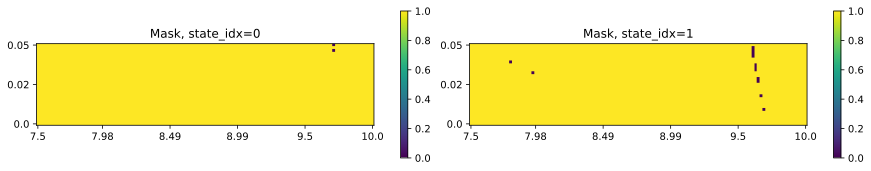

amp_idxs = [29, 59]


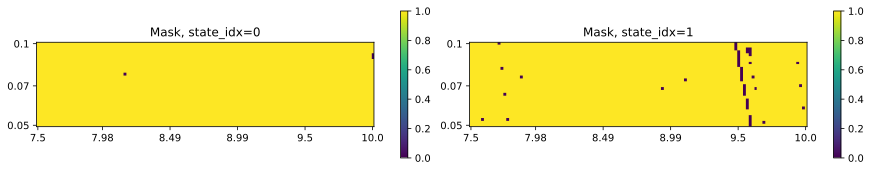

In [66]:
def fit_for_amp_range(amp_range_idx, coeffs):
    if amp_range_idx == num_fit_ranges - 1:
        amp_range_idx_final = len(displaced_state.model.drive_amplitudes)
    else:
        amp_range_idx_final = (amp_range_idx + 1) * num_amp_pts_per_range
    amp_idxs = [amp_range_idx * num_amp_pts_per_range, amp_range_idx_final]

    print(f"amp_idxs = {amp_idxs}")

    # get floquet modes for this range
    floquet_modes_for_range = new_data_dict["floquet_modes"][
        :, amp_idxs[0] : amp_idxs[1], ...
    ]

    ###########
    # bare state overlaps
    ovlp_with_bare_states = displaced_state.overlap_with_bare_states(
        coefficients=coeffs[-1],
        floquet_modes=floquet_modes_for_range,
        amp_idx_0=amp_idxs[0],
    )

    ##########
    # find mask
    mask = ovlp_with_bare_states > displaced_state.options.overlap_cutoff

    ########
    # plot the mask
    fig, ax = plt.subplots(1, 2, figsize=(12, 3), constrained_layout=True)
    for i in range(2):
        im = ax[i].imshow(mask[:, :, i].T, origin="lower")
        ax[i].set_title(f"Mask, state_idx={i}")
        fig.colorbar(im, ax=ax[i], shrink=0.7)

        xticks = omega_d_values / (2.0 * np.pi)
        yticks = chi_ac_values[amp_idxs[0] : amp_idxs[1]] / (2.0 * np.pi)

        num_x_pts = len(xticks)
        num_y_pts = len(yticks)

        xticklabel_locations = np.linspace(0, num_x_pts - 1, 6, dtype=int)
        ax[i].set_xticks(xticklabel_locations)
        ax[i].set_xticklabels(
            np.array(np.around(xticks[xticklabel_locations], decimals=2), dtype=str)
        )
        yticklabel_locations = np.linspace(0, num_y_pts - 1, 3, dtype=int)
        ax[i].set_yticks(yticklabel_locations)
        ax[i].set_yticklabels(
            np.array(np.around(yticks[yticklabel_locations], decimals=2), dtype=str)
        )

    plt.show()

    # new coeffs
    new_coefficients = displaced_state.displaced_states_fit(
        ovlp_with_bare_states, floquet_modes_for_range, amp_idxs=amp_idxs
    )

    return ovlp_with_bare_states, mask, new_coefficients


###########
amp_range_idx = 0

# previous coeffs
coeffs = [
    np.zeros(
        (
            len(displaced_state.state_indices),
            displaced_state.hilbert_dim,
            displaced_state.exponent_pairs.shape[-1],
        )
    )
]

_, _, new_coefficients = fit_for_amp_range(amp_range_idx, coeffs)

###
amp_range_idx = 1
coeffs.append(new_coefficients)
_, _, new_coefficients = fit_for_amp_range(amp_range_idx, coeffs)